In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Read dataset
df_new = pd.read_csv(r"E:\Project_Analysis\Nutri_Class_project\Data\cleaned_encoded_food_dataset.csv")

In [2]:
from sklearn.model_selection import train_test_split

X = df_new.drop(columns=["Food_Name_label"])
y = df_new["Food_Name_label"]

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [3]:
X_train

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,...,Is_Vegan_label,Is_Gluten_Free_label,Meal_Type_breakfast,Meal_Type_dinner,Meal_Type_lunch,Meal_Type_snack,Preparation_Method_baked,Preparation_Method_fried,Preparation_Method_grilled,Preparation_Method_raw
953,315.093033,13.361807,19.283340,30.334762,5.451614,3.273517,649.577870,32.309628,67.666051,51.029809,...,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
15107,212.936344,9.558935,5.125512,32.087898,3.550516,2.359933,281.651290,16.750496,64.605160,46.652223,...,0,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
12223,442.028023,19.160033,21.619570,23.065465,4.647713,1.635693,710.684692,36.051495,75.759800,49.350511,...,0,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
13737,301.543977,6.788766,10.399300,40.175241,2.926828,1.556303,0.000000,11.114009,66.403585,49.120071,...,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
23856,288.926540,4.329106,12.155107,29.311070,16.046427,2.025415,303.281983,17.925189,75.793538,46.117360,...,0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12336,289.551136,12.816637,5.284870,29.918217,4.457833,0.267388,603.966669,31.503885,82.127402,48.368640,...,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12631,469.492215,25.922433,25.571071,10.793315,0.020661,0.000000,85.240811,68.777654,36.764783,51.759753,...,0,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6926,101.694451,0.843791,0.174612,26.787861,15.933530,4.434792,0.826614,0.000000,52.752895,72.507408,...,1,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
27723,388.982142,19.102479,25.182775,10.793315,0.339249,0.000000,102.724368,68.777654,36.764783,50.406681,...,0,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [4]:
# Standard scaler 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
X_train

array([[ 0.51523058,  0.66388459,  1.09671758, ...,  1.76856461,
        -0.57747314, -0.57980774],
       [-0.644318  ,  0.05538675, -1.0734793 , ..., -0.56543029,
         1.73168227, -0.57980774],
       [ 1.9560299 ,  1.59165938,  1.45482891, ...,  1.76856461,
        -0.57747314, -0.57980774],
       ...,
       [-1.9069899 , -1.33912433, -1.83238298, ..., -0.56543029,
        -0.57747314,  1.72470963],
       [ 1.35392272,  1.58245019,  2.00101825, ..., -0.56543029,
         1.73168227, -0.57980774],
       [ 0.2400363 , -0.06452491, -0.29709538, ..., -0.56543029,
        -0.57747314, -0.57980774]], shape=(25060, 21))

In [6]:
from sklearn.svm import SVC
svm = SVC(C=5,)  #default c =1
svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",5
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [7]:
Score1 = svm.score(X_train, y_train)
Score2 = svm.score(X_test, y_test)
print(Score1, Score2)

0.9966480446927374 0.9942537909018356


In [8]:
y_pred1 = svm.predict(X_train)
y_pred2 = svm.predict(X_test)

In [9]:
# Score accuracy for prediction
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, y_pred1)
test_acc = accuracy_score(y_test, y_pred2)

print("Train accuracy after prediction :", train_acc)
print("Test accuracy after prediction:", test_acc)

Train accuracy after prediction : 0.9966480446927374
Test accuracy after prediction: 0.9942537909018356


In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred2)
cm

array([[ 292,    1,    0,    0,    0,    0,    0,    2,    0,    0],
       [   1,  236,    0,    0,    0,    0,    0,    0,    0,    0],
       [   0,    0,  982,    1,    0,    0,    5,    0,    0,    0],
       [   0,    0,    4,  887,    0,    0,    2,    0,    0,    0],
       [   0,    0,    0,    0,  592,    0,    0,    0,    1,    0],
       [   0,    0,    2,    0,    0,  790,    0,    0,    0,    0],
       [   0,    0,   12,    1,    0,    0, 1170,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0,    0,  197,    0,    0],
       [   0,    0,    0,    0,    2,    0,    0,    0,  395,    0],
       [   0,    0,    0,    0,    0,    0,    0,    0,    2,  688]])

Text(95.72222222222221, 0.5, 'Actual')

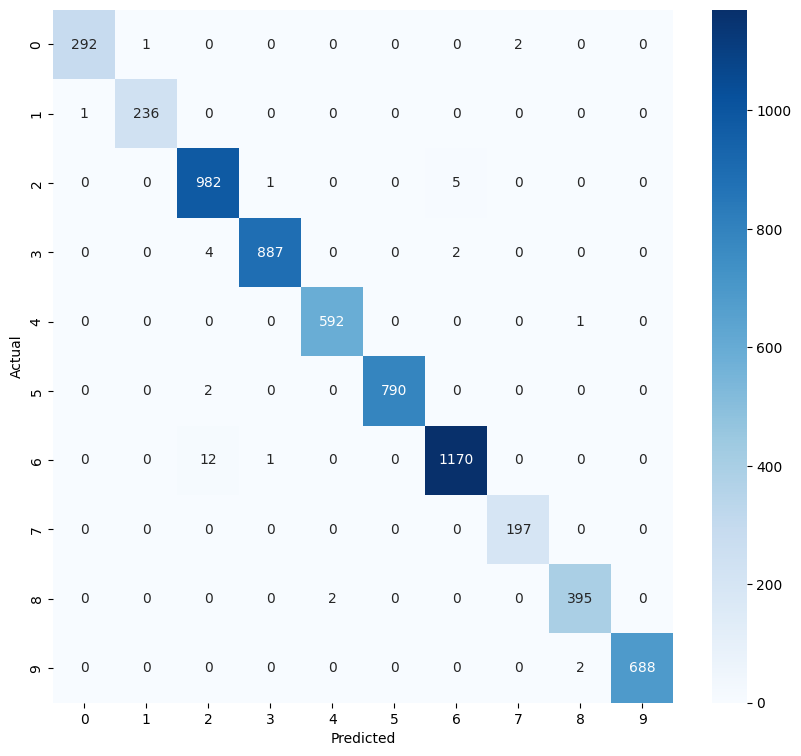

In [11]:
plt.figure(figsize = (10, 9))
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [12]:
from sklearn.metrics import classification_report

# Classification report

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred2))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       295
           1       1.00      1.00      1.00       237
           2       0.98      0.99      0.99       988
           3       1.00      0.99      1.00       893
           4       1.00      1.00      1.00       593
           5       1.00      1.00      1.00       792
           6       0.99      0.99      0.99      1183
           7       0.99      1.00      0.99       197
           8       0.99      0.99      0.99       397
           9       1.00      1.00      1.00       690

    accuracy                           0.99      6265
   macro avg       0.99      0.99      0.99      6265
weighted avg       0.99      0.99      0.99      6265



In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Candidate C values
param_grid = {
    'C': [0.01, 0.1, 1, 5, 10, 50, 100]
}

svm = SVC()

grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best C:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best C: {'C': 1}
Best CV Accuracy: 0.9945331205107741


In [14]:
results = pd.DataFrame(grid.cv_results_)

print(
    results[
        ['param_C', 'mean_test_score', 'std_test_score']
    ]
)

   param_C  mean_test_score  std_test_score
0     0.01         0.957662        0.001623
1     0.10         0.993176        0.000981
2     1.00         0.994533        0.000613
3     5.00         0.994493        0.000898
4    10.00         0.994254        0.000751
5    50.00         0.994054        0.000931
6   100.00         0.994014        0.001143
